In [ ]:
import numpy as np
import matplotlib.pyplot as plt
 
def sample_exponential(n):
    U=np.random.rand(n)
    return -np.log(1-U)
 
def compute_ecdf(data):
    s =np.sort(data)
    c=np.arange(1, len(s) + 1)/len(s)
    return s, c

#2.1

f(x)/g(x) = [3/2(e^{-x}-e^{-3x})]/e^{-x}

= 3/2(1-e^{-2x})

At x = 0: the value is (3/2)(1 - 1) = 0

As x → infinity: e^{-2x} → 0, so the value approaches 3/2

The function is strictly increasing from 0 to 3/2


In [83]:
M=3/2

considering g(x) = e^{-x}, which is Exponential(1). Its CDF is:

F(x) = integral from 0 to x of e^{-t} dt = 1-e^{-x}

To get the inverse CDF, set U = F(x) and solve for x:

U = 1-e^{-x}

e^{-x} = 1-U

x = -ln(1-U)

Since 1-U is also Uniform(0,1) when U is Uniform(0,1), you can simplify this to x = -ln(U).

In [103]:
#2.3
n_proposal= 100000
Y_prop=sample_exponential(n_proposal)

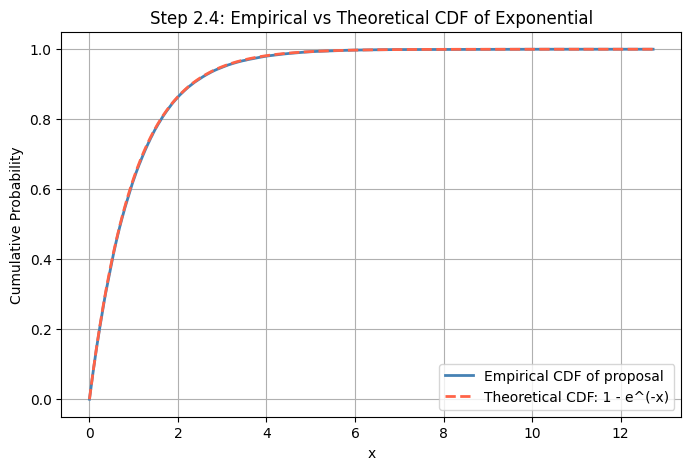

In [109]:
#2.4
x_emp, cdf_emp =compute_ecdf(Y_prop)
x_th=np.linspace(0, np.max(Y_prop), 1000)
cdf_th=1-np.exp(-x_th)
 
plt.figure(figsize=(8, 5))
plt.plot(x_emp, cdf_emp, color='steelblue', linewidth=2, label='Empirical CDF of proposal')
plt.plot(x_th,  cdf_th,  color='tomato',    linewidth=2, linestyle='--',
         label='Theoretical CDF: 1 - e^(-x)')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.title('Step 2.4: Empirical vs Theoretical CDF of Exponential')
plt.legend()
plt.grid(True)
plt.show()
 

In [110]:
#2.5
n_target=100000
accepted=[]
n_total=0
 
while len(accepted)<n_target:
    Y=sample_exponential(1)[0]
    U=np.random.rand()
    f_Y=(3/2)*(np.exp(-Y)-np.exp(-3*Y))
    g_Y=np.exp(-Y)
    if U<=f_Y/(M*g_Y):
        accepted.append(Y)
    n_total+=1
accepted=np.array(accepted)

In [111]:
#2.6
emp_mean=np.mean(accepted)
emp_var=np.var(accepted)
acceptance_rate= n_target/n_total
 
print(f"Empirical mean: {emp_mean:.5f} (theoretical: {4/3:.5f})")
print(f"Empirical variance: {emp_var:.5f} (theoretical: {10/9:.5f})")
print(f"Empirical acceptance rate:{acceptance_rate:.5f} (theoretical: {1/M:.5f})")


Empirical mean: 1.32898 (theoretical: 1.33333)
Empirical variance: 1.10317 (theoretical: 1.11111)
Empirical acceptance rate:0.66819 (theoretical: 0.66667)


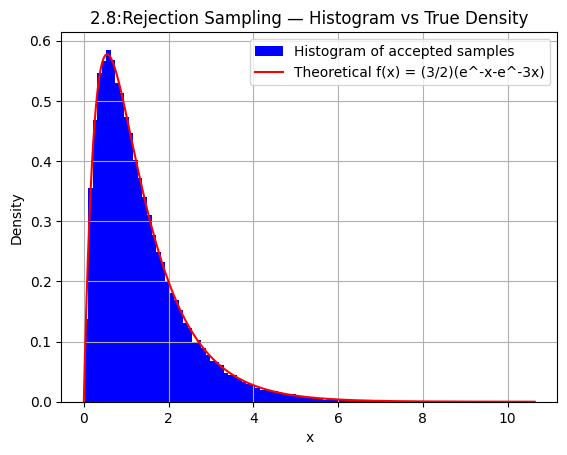

In [114]:
#2.8
x_plot= np.linspace(0, np.max(accepted), 1000)
# print(np.max(accepted))
f_plot=(3/2)*(np.exp(-x_plot)-np.exp(-3*x_plot))

plt.hist(accepted, bins=100, density=True, color='blue', label='Histogram of accepted samples')
plt.plot(x_plot, f_plot, color='red',label='Theoretical f(x) = (3/2)(e^-x-e^-3x)')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('2.8:Rejection Sampling — Histogram vs True Density')
plt.legend()
plt.grid(True)
plt.show()